In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('synthetic_it_support_tickets_.csv')
print("Shape:", df.shape)

Shape: (100000, 19)


## Data Cleaning

In [2]:
print("DATA CLEANING PIPELINE")
#Check duplicates
print("\n CHECKING DUPLICATES:")
duplicates = df.duplicated(subset=['ticket_id']).sum()
print(f"   Duplicates: {duplicates}")

DATA CLEANING PIPELINE

 CHECKING DUPLICATES:
   Duplicates: 0


In [3]:
#Outliers in resolution time
print("\n OUTLIERS DETECTION (Resolution Time):")
Q1 = df['resolution_time_hours'].quantile(0.25)
Q3 = df['resolution_time_hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['resolution_time_hours'] < lower_bound) | (df['resolution_time_hours'] > upper_bound)]
print(f"   Outliers count: {len(outliers)}")
print(f"   Upper bound: {upper_bound:.2f} hours")
print(f"   Lower bound: {lower_bound:.2f} hours")


 OUTLIERS DETECTION (Resolution Time):
   Outliers count: 6108
   Upper bound: 106.83 hours
   Lower bound: -40.29 hours


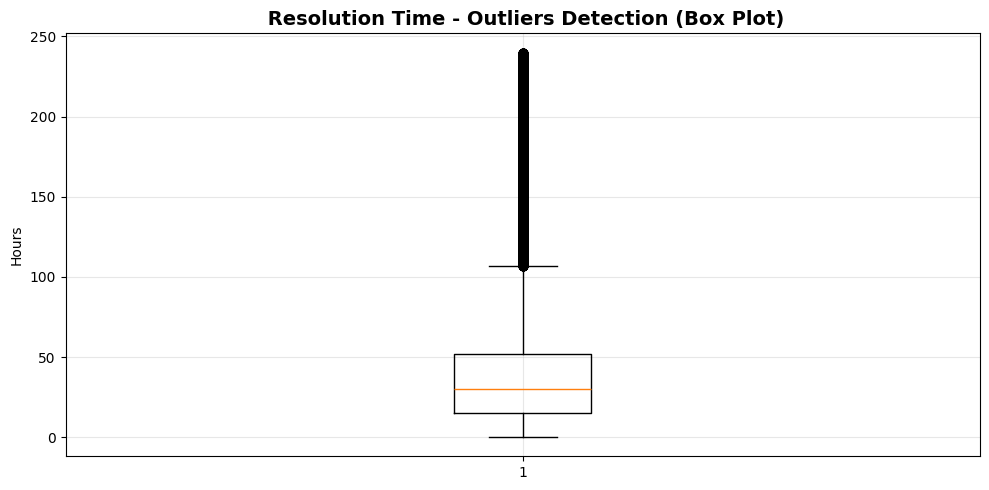

Box plot saved!


In [4]:
#BoxPlot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(df['resolution_time_hours'].dropna(), vert=True)
ax.set_title(' Resolution Time - Outliers Detection (Box Plot)', fontweight='bold', fontsize=14)
ax.set_ylabel('Hours')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Box plot saved!")

In [5]:
#Check illogical values
print("\n ILLOGICAL VALUES CHECK:")
#Resolution time < 0
negative_ttr = (df['resolution_time_hours'] < 0).sum()
print(f"Negative TTR: {negative_ttr}")


 ILLOGICAL VALUES CHECK:
Negative TTR: 0


In [6]:
#CSAT not in range 0-5
print("Not rated (0):", (df['csat_score'] == 0).mean().round(3))
invalid_csat = ((df['csat_score'] < 0) | (df['csat_score'] > 5)).sum()
print(f"   Invalid CSAT: {invalid_csat}")

Not rated (0): 0.299
   Invalid CSAT: 0


In [7]:
#Invalid status values
valid_statuses = ['resolved', 'in_progress', 'on_hold', 'open', 'closed_no_action']
invalid_status = (~df['status'].isin(valid_statuses)).sum()
print(f"   Invalid status: {invalid_status}")

#Handeling missing values
print("\n HANDLING MISSING VALUES:")

#region>Unknown
df['region'] = df['region'].fillna('Unknown')
print(f"   Region: filled with 'Unknown' ")

#resolution_summary>Pending
df['resolution_summary'] = df['resolution_summary'].fillna('Pending')
print(f"   Summary: filled with 'Pending' ")

#CAST
df['csat_score'] = df['csat_score'].replace(0, np.nan)
print("   CSAT: 0 -> NaN (not rated)")

#Remove duplicates
print("\n REMOVING DUPLICATES:")
before_drop = len(df)
df = df.drop_duplicates(subset=['ticket_id'], keep='first')

after_drop = len(df)
print(f"   Removed: {before_drop - after_drop} duplicates")
df.to_csv('cleaned_data.csv', index=False)
files.download('cleaned_data.csv')

   Invalid status: 0

 HANDLING MISSING VALUES:
   Region: filled with 'Unknown' 
   Summary: filled with 'Pending' 
   CSAT: 0 -> NaN (not rated)

 REMOVING DUPLICATES:
   Removed: 0 duplicates


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Overview

In [8]:
# Data Overview
#Load Dataset
df = pd.read_csv("cleaned_data.csv")
print("Dataset Shape:", df.shape)

#Data types
print("\nData Types:")
print(df.dtypes)

#Missing values
print("\nMissing Values:")
print(df.isnull().sum())

#Duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Ticket IDs :", df["ticket_id"].duplicated().sum())

Dataset Shape: (100000, 19)

Data Types:
ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score               float64
has_attachment             int64
platform                  object
region                    object
dtype: object

Missing Values:
ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
status                       0
sla_plan                     0
initial_message       

## EDA

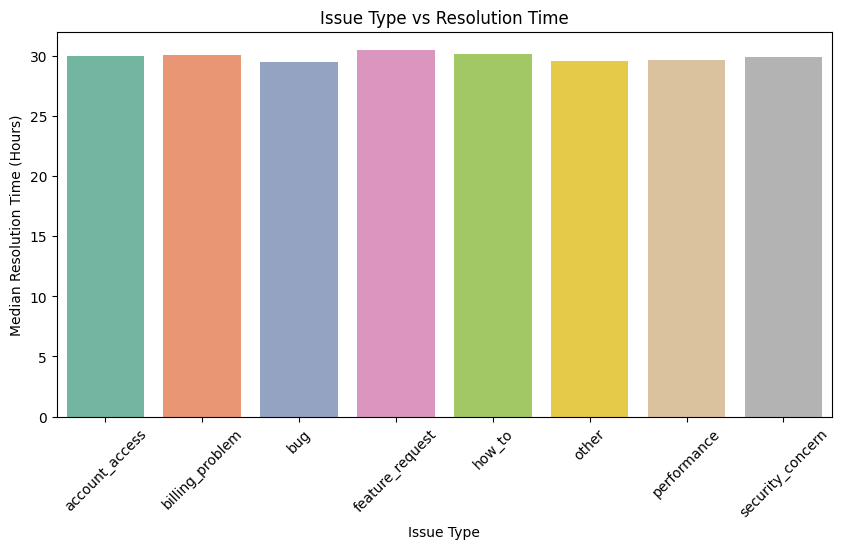

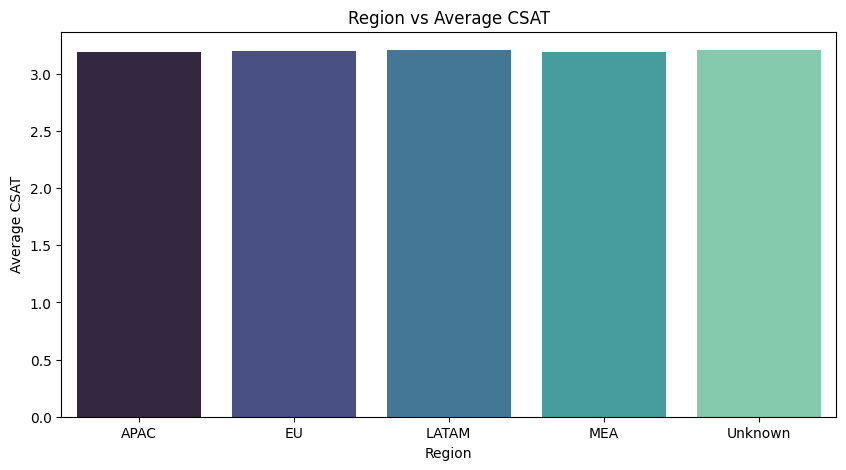

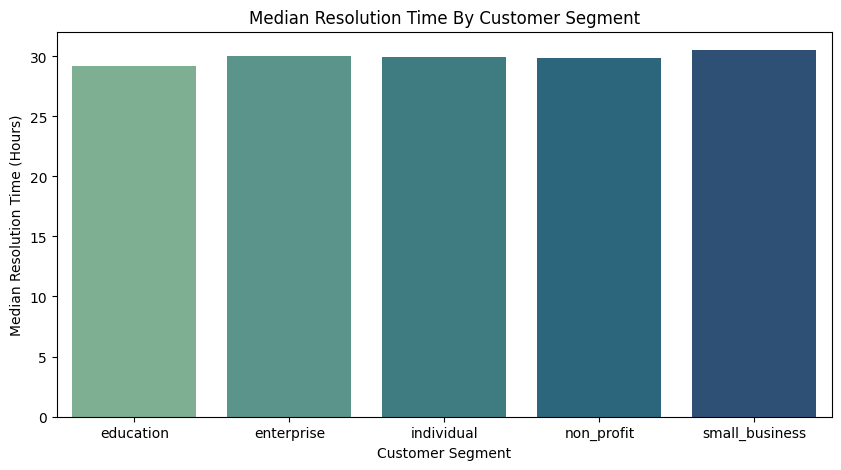

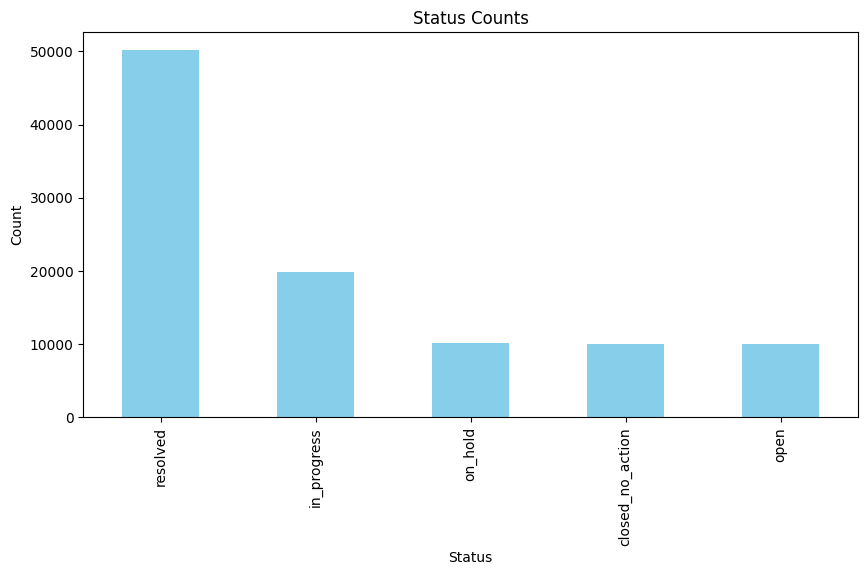

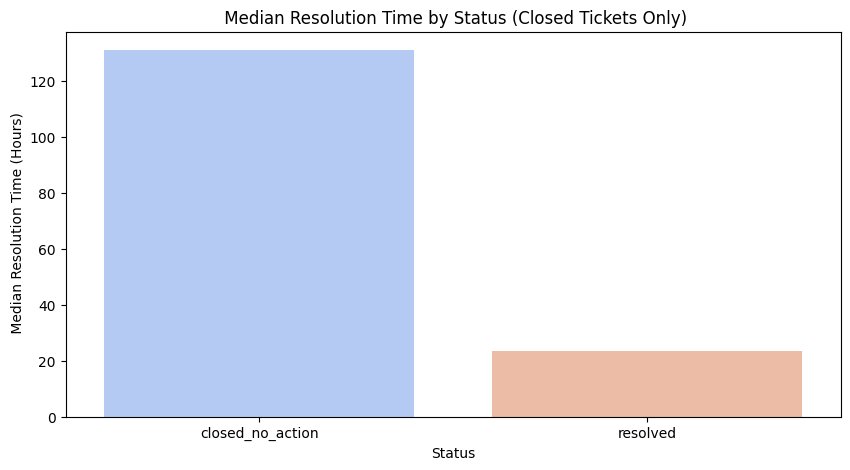

In [9]:
df = pd.read_csv("cleaned_data.csv")
df_closed = df [df["status"].isin(["resolved", "closed_no_action"]) ]
#Features and Main correlation

# Issue type & resolution time
issue_median= df_closed.groupby("issue_type")["resolution_time_hours"].median().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=issue_median , x="issue_type", y="resolution_time_hours", hue="issue_type", palette="Set2", legend=False)
plt.title("Issue Type vs Resolution Time")
plt.xlabel("Issue Type")
plt.ylabel("Median Resolution Time (Hours)")
plt.xticks(rotation= 45)
plt.show()

#Region & CSAT
region_csat = df.groupby("region")["csat_score"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=region_csat, x="region", y="csat_score",hue= "region", palette="mako", legend=False)
plt.title("Region vs Average CSAT")
plt.xlabel("Region")
plt.ylabel("Average CSAT")
plt.show()

#Custpmer segment & Resolution time
segment_median = df_closed.groupby("customer_segment")["resolution_time_hours"].median().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=segment_median , x="customer_segment", y="resolution_time_hours",hue="customer_segment", palette="crest", legend=False)
plt.title("Median Resolution Time By Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Median Resolution Time (Hours)")
plt.show()

# Status(Number of tickets depends on status)
plt.figure(figsize=(10,5))
df["status"].value_counts().plot(kind="bar", color= "skyblue")
plt.title("Status Counts")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# Status & Resolution Time
status_median = df_closed.groupby("status")["resolution_time_hours"].median().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=status_median , x="status", y="resolution_time_hours", hue="status", palette="coolwarm", legend=False)
plt.title(" Median Resolution Time by Status (Closed Tickets Only)")
plt.xlabel("Status")
plt.ylabel(" Median Resolution Time (Hours)")
plt.show()

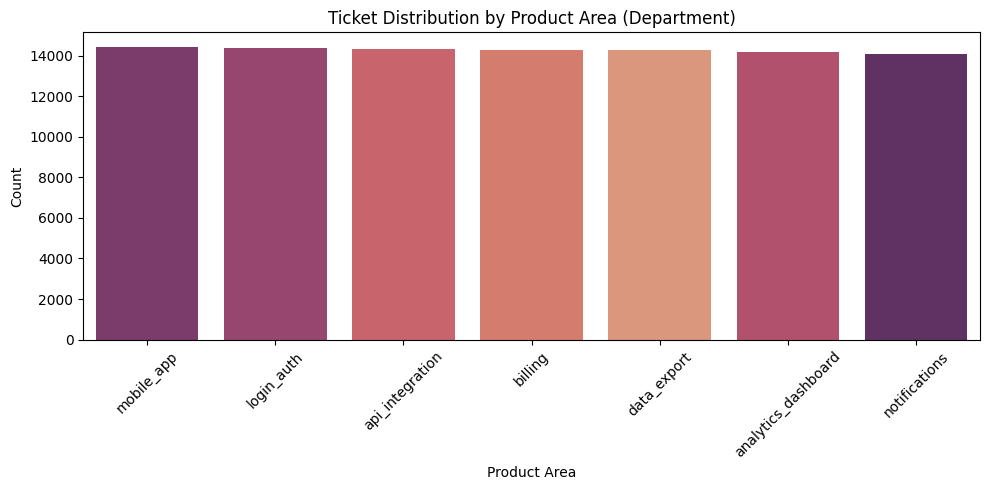

In [10]:
df = pd.read_csv("cleaned_data.csv")

#(product_area)
plt.figure(figsize=(10,5))
order = df["product_area"].value_counts().index
sns.countplot(data=df, x="product_area", order=order, hue="product_area", palette="flare", legend=False)
plt.title("Ticket Distribution by Product Area (Department)")
plt.xlabel("Product Area")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

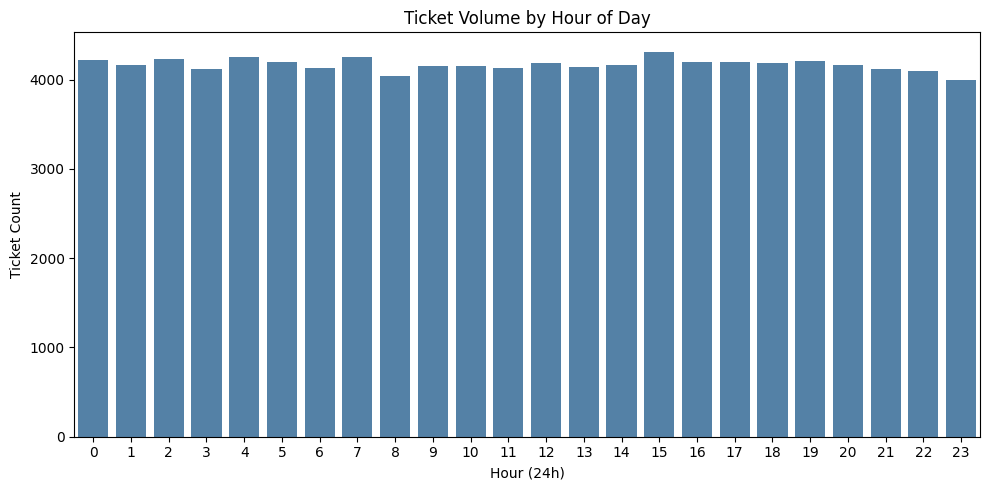

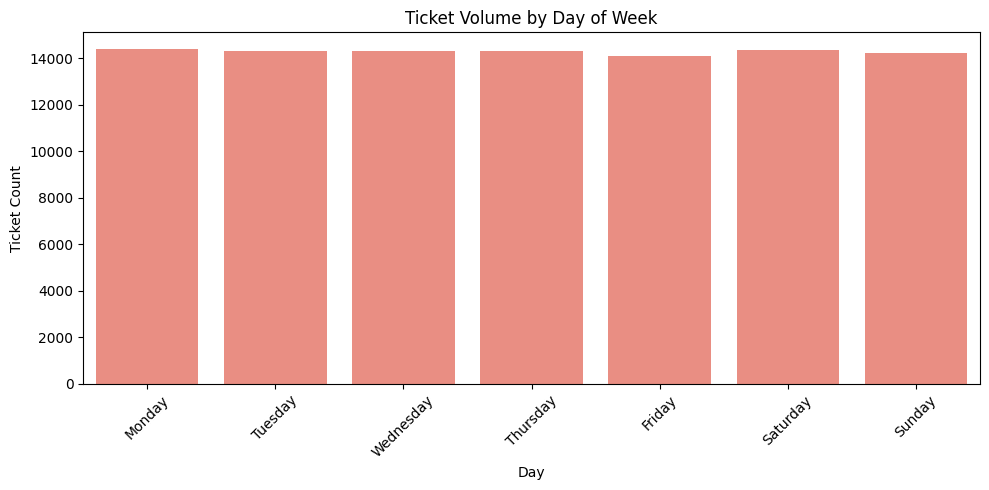

In [11]:
#Peak Submission Hours)
df["created_at"] = pd.to_datetime(df["created_at"])
df["hour"] = df["created_at"].dt.hour
df["day_of_week"] = df["created_at"].dt.day_name()


plt.figure(figsize=(10,5))
sns.countplot(data=df, x="hour", color="steelblue")
plt.title("Ticket Volume by Hour of Day")
plt.xlabel("Hour (24h)")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()


day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="day_of_week", order=day_order, color="salmon")
plt.title("Ticket Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

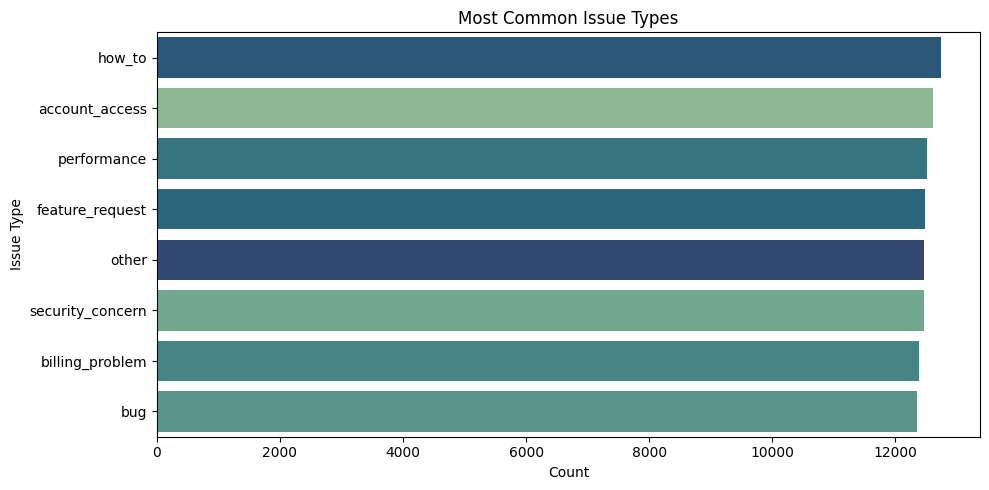

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64


In [12]:
#(Common Failure Categories)
plt.figure(figsize=(10,5))
order = df["issue_type"].value_counts().index
sns.countplot(data=df, y="issue_type", order=order, hue="issue_type", palette="crest", legend=False)
plt.title("Most Common Issue Types")
plt.xlabel("Count")
plt.ylabel("Issue Type")
plt.tight_layout()
plt.show()

print(df["issue_type"].value_counts())

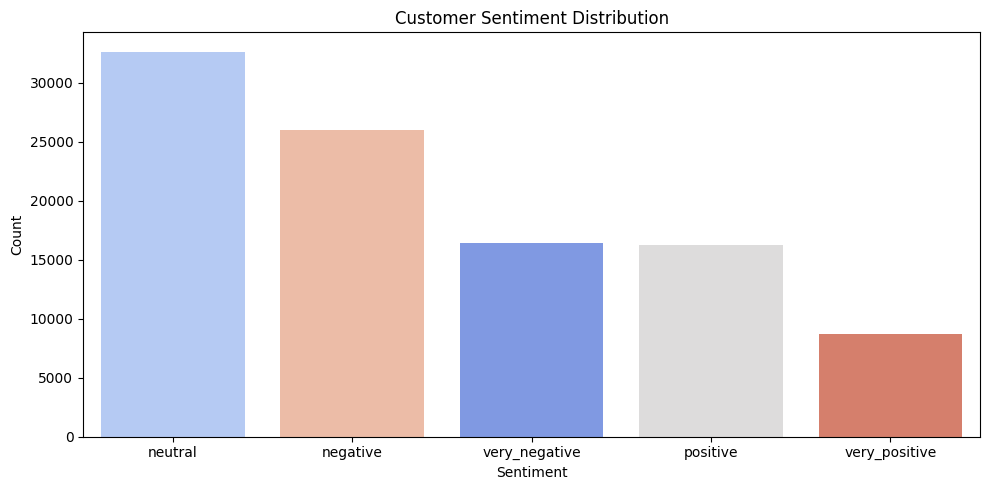

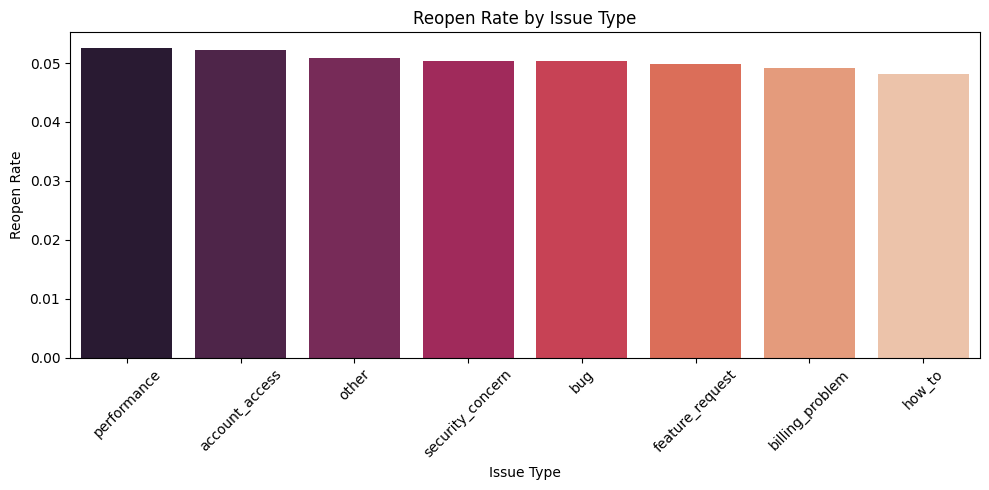

In [13]:
#customer_sentiment و reopened

plt.figure(figsize=(10,5))
order = df["customer_sentiment"].value_counts().index
sns.countplot(data=df, x="customer_sentiment", order=order, hue="customer_sentiment", palette="coolwarm", legend=False)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

reopen_rate = df.groupby("issue_type")["reopened"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=reopen_rate, x="issue_type", y="reopened", hue="issue_type", palette="rocket", legend=False)
plt.title("Reopen Rate by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Reopen Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering

In [14]:
#Create features
df["created_at"] = pd.to_datetime(df["created_at"], errors="raise")
df["hour"] = df["created_at"].dt.hour
df["day_of_week"] = df["created_at"].dt.day_name()

#Save dataset with features
df.to_csv("final_data.csv", index=False)

df

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,status,sla_plan,initial_message,...,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,hour,day_of_week
0,TCKT_000001,2024-01-31 05:14:27,CUST_00861,individual,email,data_export,account_access,resolved,standard,I cannot log in; the system says my password i...,...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1.0,0,android,EU,5,Wednesday
1,TCKT_000002,2024-10-20 06:15:49,CUST_00770,individual,in_app,billing,security_concern,closed_no_action,standard,I noticed a suspicious login on my account.,...,Ticket closed without further action after no ...,238.32,0,neutral,3.0,0,web,Unknown,6,Sunday
2,TCKT_000003,2024-06-18 21:35:54,CUST_02559,small_business,chat,api_integration,bug,in_progress,standard,The api integration feature is not saving my c...,...,Pending,NaN,0,neutral,3.0,0,android,MEA,21,Tuesday
3,TCKT_000004,2025-12-25 15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,in_progress,standard,I cannot log in; the system says my password i...,...,Pending,NaN,0,positive,5.0,1,android,LATAM,15,Thursday
4,TCKT_000005,2023-08-27 16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,resolved,gold,My invoice amount is incorrect compared to the...,...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2.0,0,web,Unknown,16,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,TCKT_099996,2023-05-16 06:23:50,CUST_06828,education,in_app,analytics_dashboard,billing_problem,resolved,standard,My invoice amount is incorrect compared to the...,...,Adjusted the invoice and issued a refund where...,7.97,0,neutral,NaN,0,desktop_app,EU,6,Tuesday
99996,TCKT_099997,2025-03-10 04:46:24,CUST_06621,education,in_app,billing,bug,resolved,standard,I am seeing an error message when I click on b...,...,Patched the bug and deployed a fix to production.,16.48,0,negative,2.0,0,api_client,MEA,4,Monday
99997,TCKT_099998,2025-11-07 19:33:01,CUST_03719,non_profit,chat,billing,bug,resolved,standard,I am seeing an error message when I click on b...,...,Patched the bug and deployed a fix to production.,56.99,0,very_positive,5.0,0,web,LATAM,19,Friday
99998,TCKT_099999,2022-06-20 22:29:10,CUST_02290,small_business,email,analytics_dashboard,account_access,open,standard,I cannot log in; the system says my password i...,...,Pending,NaN,0,neutral,NaN,1,api_client,Unknown,22,Monday


In [15]:
# Text Feature
df['message_length'] = df['initial_message'].fillna('').str.len()
df['message_words'] = df['initial_message'].fillna('').str.split().str.len()
df['has_question'] = df['initial_message'].fillna('').str.contains('?', regex=False).astype(int)
df['has_exclamation'] = df['initial_message'].fillna('').str.contains('!', regex=False).astype(int)

# Customer Feature
customer_stats = df.groupby('customer_id').agg({
    'ticket_id': 'count',
    'csat_score': 'mean'
}).rename(columns={'ticket_id': 'customer_tickets', 'csat_score': 'customer_avg_csat'})
df = df.merge(customer_stats, on='customer_id', how='left')

# Region Feature
region_stats = df.groupby('region')['csat_score'].mean().reset_index()
region_stats.rename(columns={'csat_score': 'region_avg_csat'}, inplace=True)
df = df.merge(region_stats, on='region', how='left')

In [16]:
df_before_encoding = df.copy()

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# ONE-HOT encoding
categorical_cols = ['channel', 'status', 'customer_segment', 'region', 'product_area', 'issue_type', 'platform', 'sla_plan', 'customer_sentiment']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df = df.drop(columns=['initial_message', 'agent_first_reply', 'resolution_summary', 'created_at', 'ticket_id', 'customer_id', 'day_of_week'])

df.to_csv('encoded_data.csv', index=False)
print(f"Final shape: {df.shape}")

Final shape: (100000, 51)


## Resolution Time Models

In [18]:
#df for resolution time
#Without tickets that have no resolution time
df_resolution = df.dropna(subset=['resolution_time_hours'])

In [19]:
df_resolution = df_resolution[df_resolution['status_resolved'] == 1]

leak_cols = [c for c in df_resolution.columns if c.startswith('status_')] + \
            ['csat_score', 'reopened', 'customer_avg_csat', 'region_avg_csat']
df_resolution = df_resolution.drop(columns=leak_cols)

In [20]:
# Train\Test
from sklearn.model_selection import train_test_split

X= df_resolution.drop("resolution_time_hours" , axis=1)
y= df_resolution["resolution_time_hours"]

bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=bins, random_state=42)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(loss='absolute_error', random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2:", r2_score(y_test, gb_pred))

MAE: 15.176754290831253
RMSE: 18.808654656276232
R2: -0.05160819346504719


In [22]:
!pip install -q lightgbm catboost
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

Xtr, Xte = X_train.astype(float), X_test.astype(float)

models = {
    "Baseline (median)": None,
    "GB (MAE loss)": GradientBoostingRegressor(loss='absolute_error', random_state=42),
    "HistGB (MAE loss)": HistGradientBoostingRegressor(loss='absolute_error', random_state=42),
    "XGBoost (MAE loss)": XGBRegressor(objective='reg:absoluteerror', n_estimators=500,
                                        max_depth=3, learning_rate=0.05, random_state=42),
    "LightGBM (MAE loss)": LGBMRegressor(objective='l1', n_estimators=500,
                                         learning_rate=0.05, verbose=-1, random_state=42),
    "CatBoost (MAE loss)": CatBoostRegressor(loss_function='MAE', iterations=500,
                                             verbose=0, random_state=42),
    "RF (log target)": TransformedTargetRegressor(
        RandomForestRegressor(max_depth=5, min_samples_leaf=50, n_jobs=-1, random_state=42),
        func=np.log1p, inverse_func=np.expm1),
    "Neural Network": make_pipeline(StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 32), early_stopping=True,
                     max_iter=300, random_state=42)),
}

results = []
for name, m in models.items():
    if m is None:
        pred = np.full(len(y_test), y_train.median())
    else:
        m.fit(Xtr, y_train)
        pred = m.predict(Xte)
    results.append({"Model": name,
                    "MAE": mean_absolute_error(y_test, pred),
                    "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                    "R2": r2_score(y_test, pred)})

pd.DataFrame(results).sort_values("MAE").round(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


,Model,MAE,RMSE,R2
0,Baseline (median),15.170,18.807,-0.051
1,GB (MAE loss),15.177,18.809,-0.052
2,HistGB (MAE loss),15.177,18.786,-0.049
5,CatBoost (MAE loss),15.207,18.816,-0.052
4,LightGBM (MAE loss),15.262,18.857,-0.057
3,XGBoost (MAE loss),15.269,18.501,-0.018
6,RF (log target),15.309,19.485,-0.129
7,Neural Network,15.503,18.443,-0.011


In [23]:
!pip install -q lightgbm
from lightgbm import LGBMRegressor

Xtr, Xte = X_train.astype(float), X_test.astype(float)

from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [8, 15, 31, 63],
    'min_child_samples': [20, 50, 100, 200],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
search = RandomizedSearchCV(LGBMRegressor(objective='l1', verbose=-1, random_state=42),
                            params, n_iter=30, scoring='neg_mean_absolute_error',
                            cv=5, random_state=42, n_jobs=-1)
search.fit(Xtr, y_train)
print(search.best_params_)
print("Test MAE:", mean_absolute_error(y_test, search.best_estimator_.predict(Xte)))

{'subsample': 1.0, 'num_leaves': 8, 'n_estimators': 200, 'min_child_samples': 50, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Test MAE: 15.166392946511568


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

mae = mean_absolute_error (y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print(f"MAE: {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")
print(f"R²: {r2:.2f}")

MAE: 15.75 hours
RMSE: 18.69 hours
R²: -0.04


In [25]:
baseline = np.full(len(y_test), y_train.median())
print("Baseline MAE:", mean_absolute_error(y_test, baseline))

Baseline MAE: 15.170146604168744


In [26]:
print("df shape:", df.shape)
print("df_resolution shape:", df_resolution.shape)

df shape: (100000, 51)
df_resolution shape: (50131, 43)


In [27]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid ={
    'n_estimators': [100,200,300,500],
    'max_depth': [3,5,7,10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV (
    estimator= XGBRegressor(random_state=42),
    param_distributions= param_grid,
    n_iter=20,
    scoring= 'neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Setting:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Setting: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


In [28]:
best_xgb_model = random_search.best_estimator_
best_xgb_model.fit(X_train, y_train)
print("Tuned XGB MAE:", mean_absolute_error(y_test, best_xgb_model.predict(X_test)))

Tuned XGB MAE: 15.458183557821007


In [29]:
print(df['reopened'].value_counts(normalize=True))

reopened
0    0.94955
1    0.05045
Name: proportion, dtype: float64


## Issue Type Classification

In [30]:
#Text Preprocessing proposal: lowercase, tokenization, stop-word removal, lemmatization

import re, nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english')) - {'not', 'no', 'how'}
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    tokens = re.findall(r"[a-z]+", str(text).lower())
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

unique_msgs = df_before_encoding['initial_message'].fillna('').unique()
clean_map = {m: clean_text(m) for m in unique_msgs}
df_before_encoding['clean_message'] = df_before_encoding['initial_message'].fillna('').map(clean_map)

df_before_encoding[['initial_message', 'clean_message']].drop_duplicates().head(10)

,initial_message,clean_message
0,I cannot log in; the system says my password i...,cannot log system say password incorrect
1,I noticed a suspicious login on my account.,noticed suspicious login account
2,The api integration feature is not saving my c...,api integration feature not saving change
4,My invoice amount is incorrect compared to the...,invoice amount incorrect compared plan selected
5,Queries in the mobile app module are timing out.,query mobile app module timing
7,I downgraded my plan but I am still being bill...,downgraded plan still billed higher tier
8,I was charged twice for my subscription this m...,charged twice subscription month
9,Overall performance has degraded in the last f...,overall performance degraded last day
10,Our team needs more advanced options for data ...,team need advanced option data export
13,The data export page is very slow and takes a ...,data export page slow take long time load


In [31]:
# Issue type classification Model
from sklearn.preprocessing import LabelEncoder

df_class = df_before_encoding.copy()
le_issue = LabelEncoder()
df_class['issue_type_encoded'] = le_issue.fit_transform(df_class['issue_type'])

print("Issue Type Classes:")
for i, cls in enumerate(le_issue.classes_):
    print(f"   {i}: {cls}")

Issue Type Classes:
   0: account_access
   1: billing_problem
   2: bug
   3: feature_request
   4: how_to
   5: other
   6: performance
   7: security_concern


In [32]:
#train/test
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_text = df_class['clean_message']
y_cls = df_class['issue_type_encoded']

X_tr_txt, X_te_txt, y_train_cls, y_test_cls = train_test_split(
    X_text, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_train_cls = tfidf.fit_transform(X_tr_txt)
X_test_cls = tfidf.transform(X_te_txt)

print("Train shape:", X_train_cls.shape)
print("Test shape:", X_test_cls.shape)

Train shape: (80000, 313)
Test shape: (20000, 313)


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Model : Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train_cls, y_train_cls)

rf_cls_predictions = rf_classifier.predict(X_test_cls)

# Model Evaluation
accuracy = accuracy_score(y_test_cls, rf_cls_predictions)

print(f"Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(
    y_test_cls,
    rf_cls_predictions,
    target_names=le_issue.classes_
))

Accuracy: 100.00%

Classification Report:
                  precision    recall  f1-score   support

  account_access       1.00      1.00      1.00      2522
 billing_problem       1.00      1.00      1.00      2476
             bug       1.00      1.00      1.00      2470
 feature_request       1.00      1.00      1.00      2497
          how_to       1.00      1.00      1.00      2548
           other       1.00      1.00      1.00      2493
     performance       1.00      1.00      1.00      2502
security_concern       1.00      1.00      1.00      2492

        accuracy                           1.00     20000
       macro avg       1.00      1.00      1.00     20000
    weighted avg       1.00      1.00      1.00     20000




 The 100% result is due to the repetition of just 96 messages (rote memorization rather than understanding); the true performance is a different matter entirely.

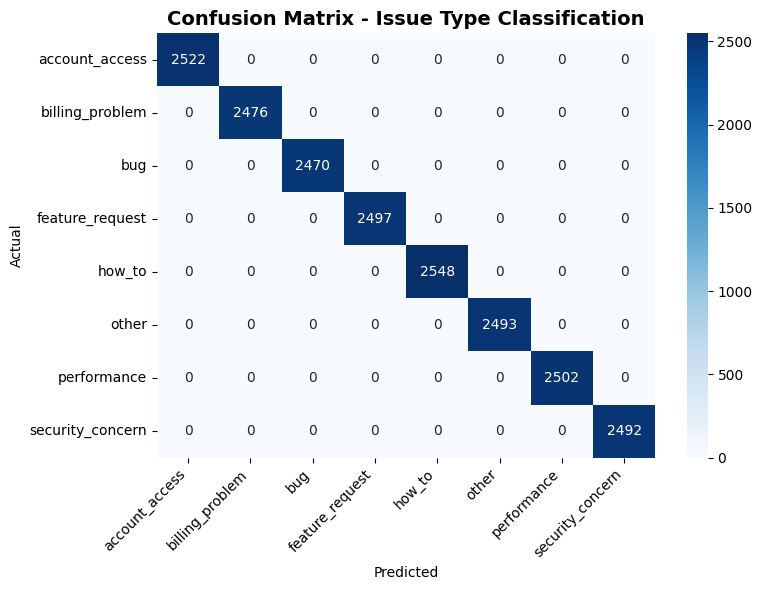

In [34]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_cls, rf_cls_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_issue.classes_, yticklabels=le_issue.classes_)
plt.title('Confusion Matrix - Issue Type Classification', fontweight='bold', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('issue_type_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

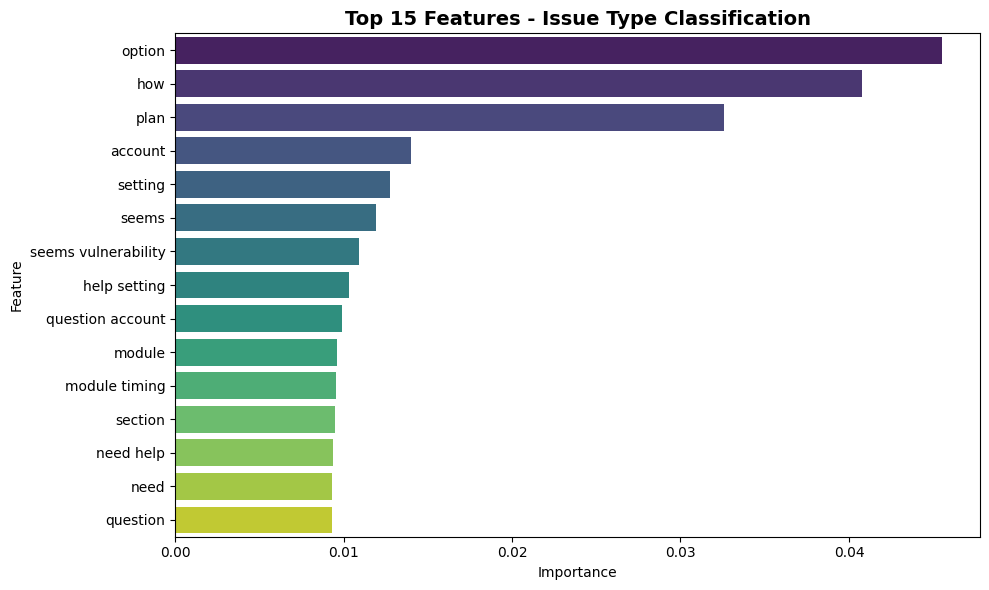

In [35]:
#features effects the issue type
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature',
            hue='feature', palette='viridis', legend=False)
plt.title('Top 15 Features - Issue Type Classification', fontweight='bold', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('issue_type_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Sanity check:

(grouped split)

In [36]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

print("Unique messages:", df_class['initial_message'].nunique(), "out of", len(df_class))
print("Each message -> one issue_type only:",
      (df_class.groupby('initial_message')['issue_type'].nunique() == 1).all())

# Grouped split
gss_cls = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
g_tr, g_te = next(gss_cls.split(X_text, y_cls, groups=df_class['initial_message']))

tfidf_g = TfidfVectorizer(ngram_range=(1, 2))
Xg_tr = tfidf_g.fit_transform(X_text.iloc[g_tr])
Xg_te = tfidf_g.transform(X_text.iloc[g_te])
lr_g = LogisticRegression(max_iter=2000).fit(Xg_tr, y_cls.iloc[g_tr])
g_pred_cls = lr_g.predict(Xg_te)

print("Grouped split (unseen messages) -> Accuracy:",
      round(accuracy_score(y_cls.iloc[g_te], g_pred_cls), 3),
      "| Macro F1:", round(f1_score(y_cls.iloc[g_te], g_pred_cls, average='macro'), 3))

# GroupKFold
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline

def group_cv(data, text_col, target_col, n_splits=5):
    X = data[text_col].fillna('')
    y = data[target_col]
    pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2)),
                         LogisticRegression(max_iter=2000, class_weight='balanced'))
    scores = cross_val_score(pipe, X, y, groups=X,
                             cv=GroupKFold(n_splits=n_splits), scoring='f1_macro')
    print(f"{target_col} - GroupKFold Macro F1: {scores.mean():.3f} ± {scores.std():.3f}")
    return scores

issue_scores = group_cv(df_class, 'clean_message', 'issue_type')

Unique messages: 96 out of 100000
Each message -> one issue_type only: True
Grouped split (unseen messages) -> Accuracy: 0.568 | Macro F1: 0.629
issue_type - GroupKFold Macro F1: 0.605 ± 0.107


## Team Routing

In [37]:
# Team Routing:(product_area)
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

df_route = df_before_encoding.copy()
df_route['initial_message'] = df_route['initial_message'].fillna('')

TEXT_COL = 'initial_message'
#Columns available only at the moment the ticket is opened. (without status / csat / resolution = leakage)
CAT_COLS = ['channel', 'platform', 'customer_segment']
TARGET = 'product_area'

print(df_route[TARGET].value_counts())
print("\nUnique messages:", df_route[TEXT_COL].nunique(), "out of", len(df_route))

product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64

Unique messages: 96 out of 100000


In [38]:
# Train / Test split (stratified To maintain the departmental ratios)
X_r = df_route[[TEXT_COL] + CAT_COLS]
y_r = df_route[TARGET]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42, stratify=y_r)
print("Train:", X_train_r.shape, " Test:", X_test_r.shape)

Train: (80000, 4)  Test: (20000, 4)


In [39]:
# Preprocessing:text VS text+ metadata
tfidf_params = dict(ngram_range=(1, 2), min_df=2, stop_words='english')

# دوال ترجع نسخة جديدة كل مرة، عشان كل موديل يكون له preprocessor مستقل
def prep_text_only():
    return ColumnTransformer([
        ('text', TfidfVectorizer(**tfidf_params), TEXT_COL),
    ])

def prep_text_meta():
    return ColumnTransformer([
        ('text', TfidfVectorizer(**tfidf_params), TEXT_COL),
        ('cat',  OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
    ])

In [40]:
#Model Training and Comparison
routing_models = {
    "Baseline (most frequent)": Pipeline([
        ('prep', prep_text_only()),
        ('clf', DummyClassifier(strategy='most_frequent'))]),
    "LogReg (text)": Pipeline([
        ('prep', prep_text_only()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    "LogReg (text + meta)": Pipeline([
        ('prep', prep_text_meta()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    "LinearSVC (text + meta)": Pipeline([
        ('prep', prep_text_meta()),
        ('clf', LinearSVC(class_weight='balanced'))]),
    "RandomForest (text + meta)": Pipeline([
        ('prep', prep_text_meta()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       n_jobs=-1, random_state=42))]),
}

routing_results, fitted = [], {}
for name, pipe in routing_models.items():
    pipe.fit(X_train_r, y_train_r)
    pred = pipe.predict(X_test_r)
    fitted[name] = pipe
    routing_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_r, pred),
        "Macro F1": f1_score(y_test_r, pred, average='macro'),
    })

routing_results_df = pd.DataFrame(routing_results).sort_values("Macro F1", ascending=False).round(3)
routing_results_df

,Model,Accuracy,Macro F1
1,LogReg (text),0.574,0.580
2,LogReg (text + meta),0.573,0.575
3,LinearSVC (text + meta),0.572,0.575
4,RandomForest (text + meta),0.574,0.574
0,Baseline (most frequent),0.144,0.036


Best model: LogReg (text)
                     precision    recall  f1-score   support

analytics_dashboard       0.40      0.66      0.50      2837
    api_integration       0.54      0.60      0.57      2870
            billing       0.69      0.53      0.60      2858
        data_export       0.69      0.54      0.60      2852
         login_auth       0.54      0.59      0.57      2876
         mobile_app       0.69      0.54      0.60      2887
      notifications       0.69      0.55      0.61      2820

           accuracy                           0.57     20000
          macro avg       0.61      0.57      0.58     20000
       weighted avg       0.61      0.57      0.58     20000



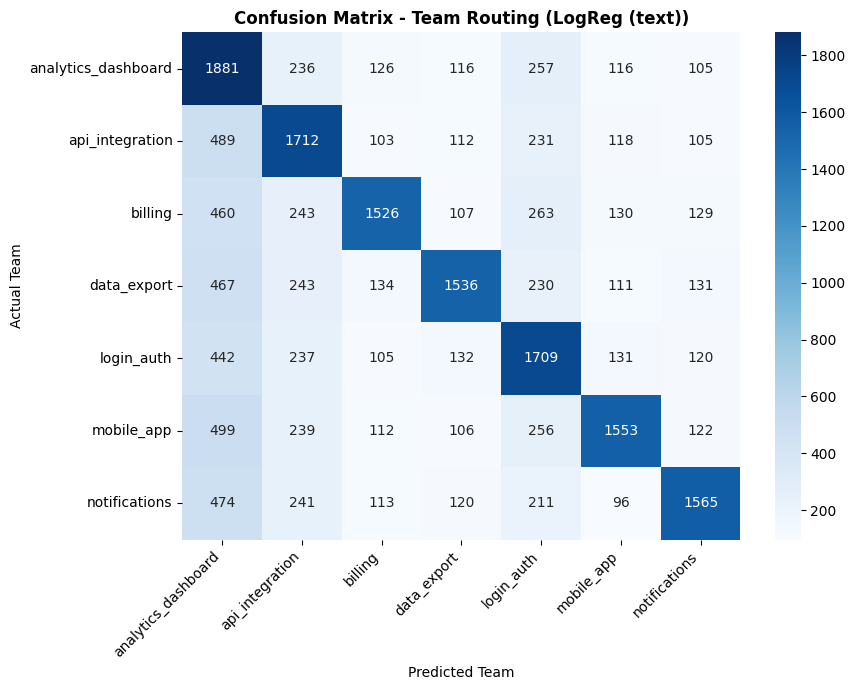

In [41]:
#Confusion Matrix for best model + Detailed report
best_name = routing_results_df.iloc[0]["Model"]
best_route_model = fitted[best_name]
best_pred = best_route_model.predict(X_test_r)

print("Best model:", best_name)
print(classification_report(y_test_r, best_pred))

labels = sorted(y_r.unique())
cm_r = confusion_matrix(y_test_r, best_pred, labels=labels)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - Team Routing ({best_name})', fontweight='bold')
plt.xlabel('Predicted Team'); plt.ylabel('Actual Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('routing_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Top-3 Accuracy:
lr_route = fitted["LogReg (text + meta)"]
proba = lr_route.predict_proba(X_test_r)
top3 = lr_route.classes_[np.argsort(proba, axis=1)[:, -3:]]
top3_acc = np.mean([t in row for t, row in zip(y_test_r.values, top3)])
print(f"Top-1 Accuracy: {accuracy_score(y_test_r, lr_route.predict(X_test_r)):.3f}")
print(f"Top-3 Accuracy: {top3_acc:.3f}")

Top-1 Accuracy: 0.573
Top-3 Accuracy: 0.716


In [43]:
#Error Analysis: Examples Incorrectly Handled by the Model
errors = X_test_r.copy()
errors['actual'] = y_test_r.values
errors['predicted'] = best_pred
errors = errors[errors['actual'] != errors['predicted']]
print("Errors Number :", len(errors))
pd.set_option('display.max_colwidth', 120)
errors[[TEXT_COL, 'actual', 'predicted']].head(15)

Errors Number : 8518


,initial_message,actual,predicted
39766,I noticed a suspicious login on my account.,billing,notifications
65469,I noticed a suspicious login on my account.,login_auth,notifications
16989,Overall performance has degraded in the last few days.,api_integration,login_auth
92466,My 2FA code is not working when I try to sign in.,analytics_dashboard,billing
50225,I need help but I'm not sure which category this fits in.,notifications,analytics_dashboard
44266,I was charged twice for my subscription this month.,billing,analytics_dashboard
91379,I need help but I'm not sure which category this fits in.,mobile_app,analytics_dashboard
75938,"Something seems off, can you please check my workspace?",analytics_dashboard,data_export
57742,Overall performance has degraded in the last few days.,data_export,login_auth
33259,I was charged twice for my subscription this month.,mobile_app,analytics_dashboard


In [44]:
# Sanity check:We divide them so that each message falls into only one category (template matching).
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(X_r, y_r, groups=X_r[TEXT_COL]))

check = Pipeline([
    ('prep', prep_text_meta()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
check.fit(X_r.iloc[tr_idx], y_r.iloc[tr_idx])
g_pred = check.predict(X_r.iloc[te_idx])
print("Grouped split -> Accuracy:", round(accuracy_score(y_r.iloc[te_idx], g_pred), 3),
      "| Macro F1:", round(f1_score(y_r.iloc[te_idx], g_pred, average='macro'), 3))

team_scores = group_cv(df_before_encoding, 'initial_message', 'product_area')

Grouped split -> Accuracy: 0.63 | Macro F1: 0.659
product_area - GroupKFold Macro F1: 0.516 ± 0.112


In [45]:
#Routing function for a new ticket (for the dashboard)
def route_ticket(message, channel, platform, customer_segment, model=lr_route, k=3):
    row = pd.DataFrame([{TEXT_COL: message, 'channel': channel,
                         'platform': platform, 'customer_segment': customer_segment}])
    p = model.predict_proba(row)[0]
    order = np.argsort(p)[::-1][:k]
    return [(model.classes_[i], round(float(p[i]), 3)) for i in order]

sample = X_test_r.iloc[0]
print(sample[TEXT_COL])
print(route_ticket(sample[TEXT_COL], sample['channel'], sample['platform'], sample['customer_segment']))

I noticed a suspicious login on my account.
[('api_integration', 0.148), ('mobile_app', 0.145), ('login_auth', 0.145)]


BERT Embeddings vs. TF-IDF
Testing the proposal hypothesis: Is BERT text representation superior to word-based methods (TF-IDF)?

We use a pre-trained Sentence-BERT model (`all-MiniLM-L6-v2`) to extract embeddings.
We did not perform fine-tuning because the dataset contains only 96 unique messages; fine-tuning on such a small set would cause the model to memorize the data rather than understand it.

We compare using two splitting methods:
Random split: The model might have already seen the test messages during training.
Grouped split: The test messages are completely new to the model; this serves as the true test of comprehension.

In [46]:
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer

bert = SentenceTransformer('all-MiniLM-L6-v2')

#We calculate the embedding for each unique message once, then distribute it across all the rows.
msgs = df_before_encoding['initial_message'].fillna('')
unique_msgs = msgs.unique()
unique_emb = bert.encode(list(unique_msgs), batch_size=64, show_progress_bar=True)

X_bert = unique_emb[pd.Index(unique_msgs).get_indexer(msgs)]
print("BERT embeddings shape:", X_bert.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

BERT embeddings shape: (100000, 384)


In [47]:
texts = msgs.values
tasks = {'Issue Type': df_before_encoding['issue_type'].values,
         'Team Routing': df_before_encoding['product_area'].values}

def get_splits(y_task):
    rnd = train_test_split(np.arange(len(y_task)), test_size=0.2, random_state=42, stratify=y_task)
    grp = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
               .split(texts, y_task, groups=texts))
    return {'Random split': rnd, 'Grouped split (unseen messages)': grp}

rows = []
for task, y_task in tasks.items():
    for split_name, (tr, te) in get_splits(y_task).items():
        # TF-IDF + Logistic Regression
        vec = TfidfVectorizer(ngram_range=(1, 2))
        p_tfidf = LogisticRegression(max_iter=2000).fit(
            vec.fit_transform(texts[tr]), y_task[tr]).predict(vec.transform(texts[te]))
        # BERT embeddings + Logistic Regression
        p_bert = LogisticRegression(max_iter=2000).fit(
            X_bert[tr], y_task[tr]).predict(X_bert[te])

        for model_name, p in [('TF-IDF + LogReg', p_tfidf), ('BERT + LogReg', p_bert)]:
            rows.append({'Task': task, 'Split': split_name, 'Model': model_name,
                         'Accuracy': accuracy_score(y_task[te], p),
                         'Macro F1': f1_score(y_task[te], p, average='macro')})

bert_vs_tfidf = pd.DataFrame(rows).round(3)
bert_vs_tfidf

,Task,Split,Model,Accuracy,Macro F1
0,Issue Type,Random split,TF-IDF + LogReg,1.000,1.000
1,Issue Type,Random split,BERT + LogReg,1.000,1.000
2,Issue Type,Grouped split (unseen messages),TF-IDF + LogReg,0.568,0.629
3,Issue Type,Grouped split (unseen messages),BERT + LogReg,0.568,0.629
4,Team Routing,Random split,TF-IDF + LogReg,0.575,0.590
5,Team Routing,Random split,BERT + LogReg,0.573,0.580
6,Team Routing,Grouped split (unseen messages),TF-IDF + LogReg,0.630,0.662
7,Team Routing,Grouped split (unseen messages),BERT + LogReg,0.629,0.634


The "Grouped split" results here are based on a single split and may vary by a few points. The more accurate result (GroupKFold with 5 splits) can be found in the "Sanity check" cells for "Issue Type" and "Team Routing."

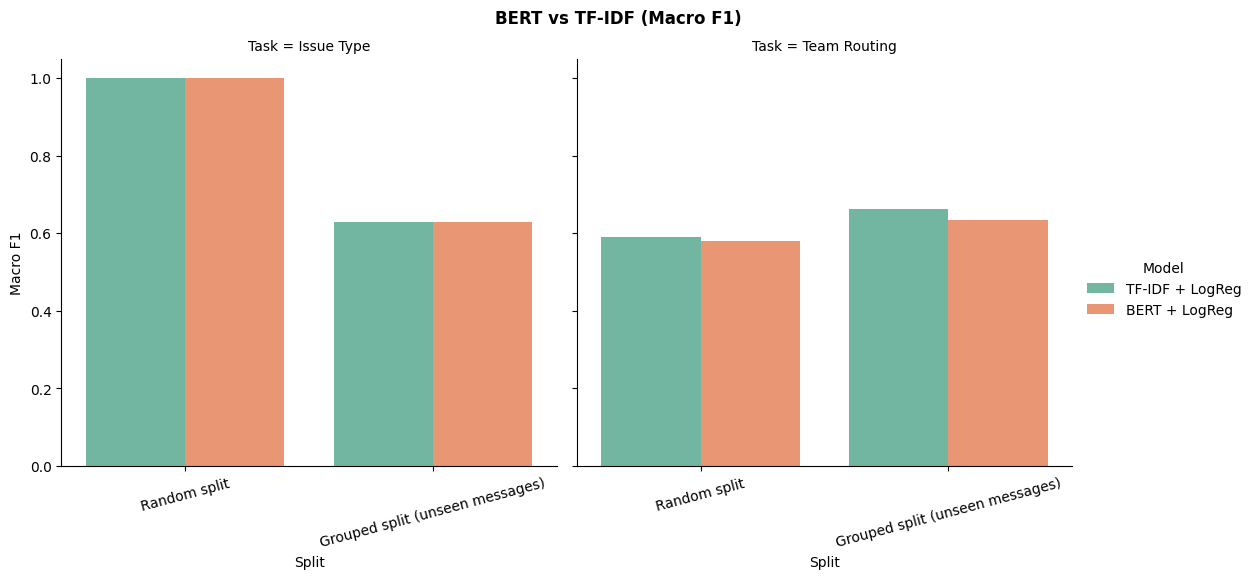

In [48]:
g = sns.catplot(data=bert_vs_tfidf, x='Split', y='Macro F1', hue='Model',
                col='Task', kind='bar', height=5, aspect=1.1, palette='Set2')
g.set_xticklabels(rotation=15)
g.fig.suptitle('BERT vs TF-IDF (Macro F1)', fontweight='bold', y=1.03)
g.savefig('bert_vs_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()

## Resolution Time Prediction

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare Data
X = df_resolution.drop('resolution_time_hours', axis=1)
y = df_resolution['resolution_time_hours']

# Stratified Split
bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=bins,
    random_state=42
)

#Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Predict
predictions = rf_model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Resolution Time Prediction Results:")
print(f"MAE: {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")
print(f"R²: {r2:.2f}")

Resolution Time Prediction Results:
MAE: 15.75 hours
RMSE: 18.69 hours
R²: -0.04


Why are all the models close to the baseline?
We measure the amount of information each feature provides regarding the solution time (Mutual Information). Values ​​close to zero indicate that the feature does not help with prediction.

channel_web_form                0.0073
hour                            0.0063
has_attachment                  0.0062
has_question                    0.0051
channel_email                   0.0042
message_length                  0.0041
issue_type_how_to               0.0039
sla_plan_platinum               0.0034
region_LATAM                    0.0032
product_area_login_auth         0.0032
product_area_data_export        0.0022
customer_segment_individual     0.0021
platform_desktop_app            0.0018
product_area_api_integration    0.0013
region_Unknown                  0.0012
dtype: float64


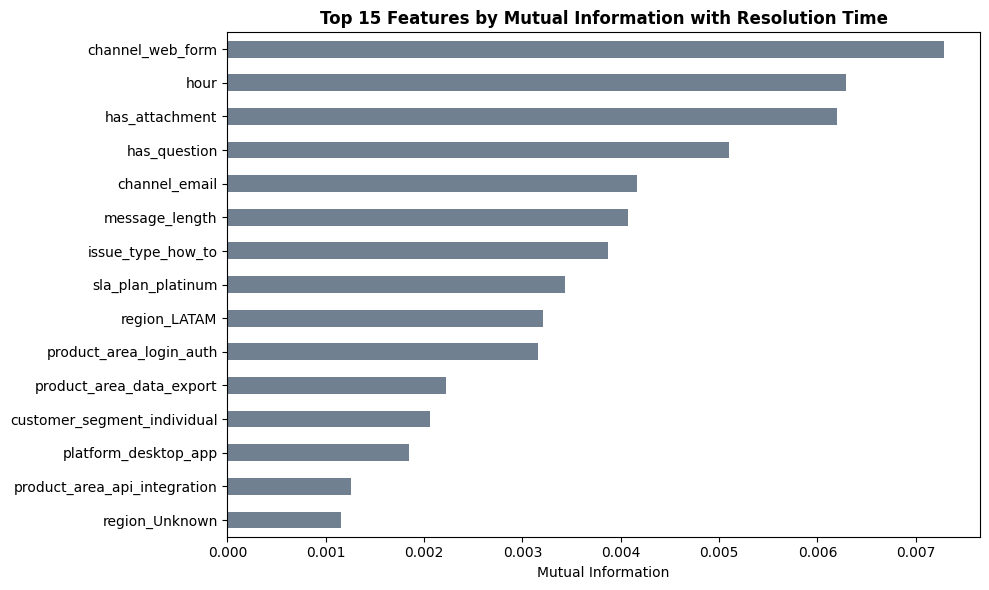

In [50]:
from sklearn.feature_selection import mutual_info_regression

sample_idx = X_train.sample(min(10000, len(X_train)), random_state=42).index
mi = mutual_info_regression(X_train.loc[sample_idx].astype(float),
                            y_train.loc[sample_idx], random_state=42)
mi_df = pd.Series(mi, index=X_train.columns).sort_values(ascending=False).head(15)
print(mi_df.round(4))

plt.figure(figsize=(10, 6))
mi_df.sort_values().plot(kind='barh', color='slategray')
plt.title('Top 15 Features by Mutual Information with Resolution Time', fontweight='bold')
plt.xlabel('Mutual Information')
plt.tight_layout()
plt.savefig('resolution_time_mutual_info.png', dpi=300, bbox_inches='tight')
plt.show()

## Anomaly Detection

In [51]:
#We start with the clean version (before any encoding) because it contains `created_at` in its raw form.
df_anomaly = df_before_encoding.copy()

#Convert `created_at` to a datetime object so we can work with it as an actual time value.
df_anomaly['created_at'] = pd.to_datetime(df_anomaly['created_at'])

#Quick confirmation
print(df_anomaly['created_at'].min(), "->", df_anomaly['created_at'].max())
print(df_anomaly.dtypes['created_at'])

2022-01-01 00:16:58 -> 2025-12-30 23:45:45
datetime64[ns]


In [52]:
#We set `created_at` as the index so we can use `resample`.
df_anomaly = df_anomaly.set_index('created_at')

#Hourly aggregation (you can change the 'D' to 'Day' if the hourly data volume is low).
hourly = df_anomaly.resample('h').agg(
    ticket_count=('ticket_id', 'count'),
    avg_resolution_time=('resolution_time_hours', 'mean'),
    reopened_rate=('reopened', 'mean')
).fillna(0)

print(hourly.shape)
hourly.head()

(35040, 3)


,ticket_count,avg_resolution_time,reopened_rate
created_at,,,
2022-01-01 00:00:00,4,19.446667,0.0
2022-01-01 01:00:00,4,96.390000,0.0
2022-01-01 02:00:00,2,55.060000,0.0
2022-01-01 03:00:00,2,20.260000,0.0
2022-01-01 04:00:00,3,18.785000,0.0


In [53]:
print(hourly['ticket_count'].describe())
print(hourly['ticket_count'].value_counts().sort_index())

count    35040.000000
mean         2.853881
std          1.696077
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         13.000000
Name: ticket_count, dtype: float64
ticket_count
0     2025
1     5772
2     8303
3     7688
4     5601
5     3183
6     1519
7      616
8      225
9       75
10      27
11       5
13       1
Name: count, dtype: int64


In [54]:
daily = df_anomaly.resample('D').agg(
    ticket_count=('ticket_id', 'count'),
    avg_resolution_time=('resolution_time_hours', 'mean'),
    reopened_rate=('reopened', 'mean')
).fillna(0)

print(daily['ticket_count'].describe())

count    1460.000000
mean       68.493151
std         8.107610
min        43.000000
25%        63.000000
50%        68.000000
75%        74.000000
max        95.000000
Name: ticket_count, dtype: float64


In [55]:
from sklearn.ensemble import IsolationForest

features = ['ticket_count', 'avg_resolution_time', 'reopened_rate']
X_daily = daily[features]

iso_forest_daily = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

daily['anomaly_score'] = iso_forest_daily.fit_predict(X_daily)

print(daily['anomaly_score'].value_counts())

anomaly_score
 1    1387
-1      73
Name: count, dtype: int64


In [56]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(daily[features])
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
daily['lof_anomaly'] = lof.fit_predict(X_scaled)

#Comparison: How many days did the two models agree on?
print(pd.crosstab(daily['anomaly_score'], daily['lof_anomaly'],
                  rownames=['IsolationForest'], colnames=['LOF']))

LOF              -1     1
IsolationForest          
-1               45    28
 1               28  1359


In [57]:
consensus = daily[(daily['anomaly_score'] == -1) & (daily['lof_anomaly'] == -1)]
print("High-confidence anomalies:", len(consensus))
consensus.sort_values('ticket_count', ascending=False).head(10)

High-confidence anomalies: 45


,ticket_count,avg_resolution_time,reopened_rate,anomaly_score,lof_anomaly
created_at,,,,,
2025-03-29,95,37.267872,0.021053,-1,-1
2023-03-28,93,50.095667,0.053763,-1,-1
2023-07-28,93,40.606200,0.075269,-1,-1
2022-11-16,92,53.691111,0.076087,-1,-1
2022-04-11,92,47.150755,0.043478,-1,-1
2024-10-10,92,42.401091,0.097826,-1,-1
2024-08-16,89,60.340741,0.044944,-1,-1
2025-12-19,89,34.607358,0.022472,-1,-1
2023-12-14,85,28.916250,0.070588,-1,-1


In [58]:
anomalies_daily = daily[daily['anomaly_score'] == -1]
anomalies_daily.sort_values('ticket_count', ascending=False).head(10)

,ticket_count,avg_resolution_time,reopened_rate,anomaly_score,lof_anomaly
created_at,,,,,
2025-03-29,95,37.267872,0.021053,-1,-1
2023-07-28,93,40.606200,0.075269,-1,-1
2023-03-28,93,50.095667,0.053763,-1,-1
2022-11-16,92,53.691111,0.076087,-1,-1
2023-12-18,92,49.427241,0.043478,-1,1
2024-10-10,92,42.401091,0.097826,-1,-1
2023-07-16,92,46.920000,0.054348,-1,1
2022-04-11,92,47.150755,0.043478,-1,-1
2024-08-16,89,60.340741,0.044944,-1,-1


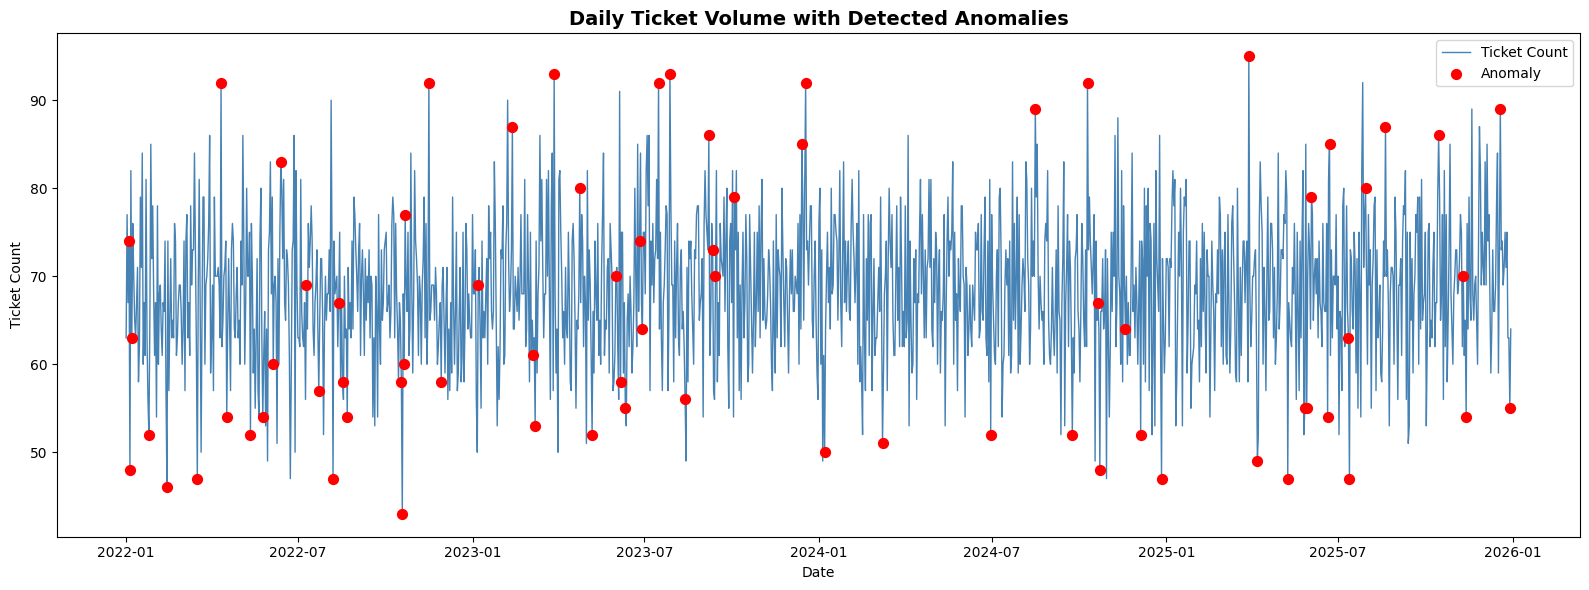

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

#Baseline: Number of tickets over time
plt.plot(daily.index, daily['ticket_count'], color='steelblue', linewidth=1, label='Ticket Count')

#Marking outliers with red dots above the line.
plt.scatter(anomalies_daily.index, anomalies_daily['ticket_count'],
            color='red', s=50, zorder=5, label='Anomaly')

plt.title('Daily Ticket Volume with Detected Anomalies', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Ticket Count')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_detection_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

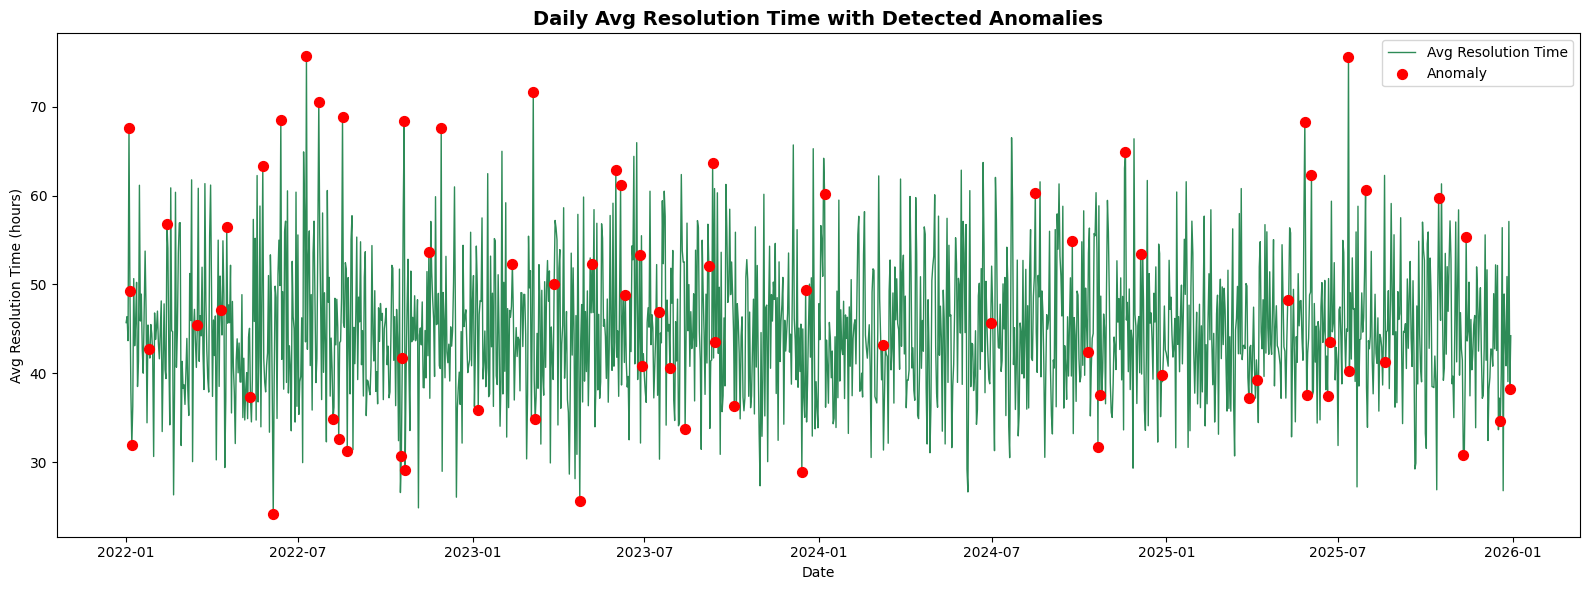

In [60]:
plt.figure(figsize=(16, 6))

#Baseline: Average daily resolution time over time
plt.plot(daily.index, daily['avg_resolution_time'], color='seagreen', linewidth=1, label='Avg Resolution Time')

#Marking outliers with red dots above the line.
plt.scatter(anomalies_daily.index, anomalies_daily['avg_resolution_time'],
            color='red', s=50, zorder=5, label='Anomaly')

plt.title('Daily Avg Resolution Time with Detected Anomalies', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Avg Resolution Time (hours)')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_resolution_time.png', dpi=300, bbox_inches='tight')
plt.show()

# Anomaly Detection by Issue Type:

In [61]:
#Let's go back to the same `df_anomaly` (where `created_at` is a datetime and `issue_type` is still in its original format).
df_anomaly_type = df_before_encoding.copy()
df_anomaly_type['created_at'] = pd.to_datetime(df_anomaly_type['created_at'])
df_anomaly_type = df_anomaly_type.set_index('created_at')

# Pivot: Each row = a day, each column = a ticket type, and the value = the number of tickets of that type on that day.
daily_by_type = df_anomaly_type.groupby([pd.Grouper(freq='D'), 'issue_type']).size().unstack(fill_value=0)

print(daily_by_type.shape)
daily_by_type.head()

(1460, 8)


issue_type,account_access,billing_problem,bug,feature_request,how_to,other,performance,security_concern
created_at,,,,,,,,
2022-01-01,6,5,8,12,7,7,8,10
2022-01-02,12,15,10,8,8,11,7,6
2022-01-03,10,9,8,8,8,8,11,5
2022-01-04,5,5,6,10,12,11,14,11
2022-01-05,6,3,5,3,7,6,9,9


In [62]:
from sklearn.ensemble import IsolationForest

iso_forest_type = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

daily_by_type['anomaly_score'] = iso_forest_type.fit_predict(daily_by_type)

print(daily_by_type['anomaly_score'].value_counts())

anomaly_score
 1    1387
-1      73
Name: count, dtype: int64


In [63]:
anomalies_by_type = daily_by_type[daily_by_type['anomaly_score'] == -1].copy()

#We add a column indicating which ticket type was highest on that anomalous day (to aid interpretation).
issue_cols = [col for col in daily_by_type.columns if col != 'anomaly_score']
anomalies_by_type['dominant_issue_type'] = anomalies_by_type[issue_cols].idxmax(axis=1)

anomalies_by_type[issue_cols + ['dominant_issue_type']].head(10)

issue_type,account_access,billing_problem,bug,feature_request,how_to,other,performance,security_concern,dominant_issue_type
created_at,,,,,,,,,
2022-01-22,8,18,9,6,13,13,9,5,billing_problem
2022-01-29,7,7,8,16,5,20,9,6,other
2022-03-17,4,6,3,10,9,6,7,2,feature_request
2022-03-28,13,5,7,5,15,11,4,12,how_to
2022-03-30,16,7,6,11,15,10,14,7,account_access
2022-04-16,9,9,4,5,4,16,13,14,other
2022-04-23,11,9,3,5,15,8,15,10,how_to
2022-05-04,13,16,14,11,7,7,12,6,billing_problem
2022-05-28,6,2,4,11,5,12,7,6,other


spiking_issue_type
other               12
billing_problem     11
how_to              11
account_access      10
performance          9
feature_request      7
bug                  7
security_concern     6
Name: count, dtype: int64


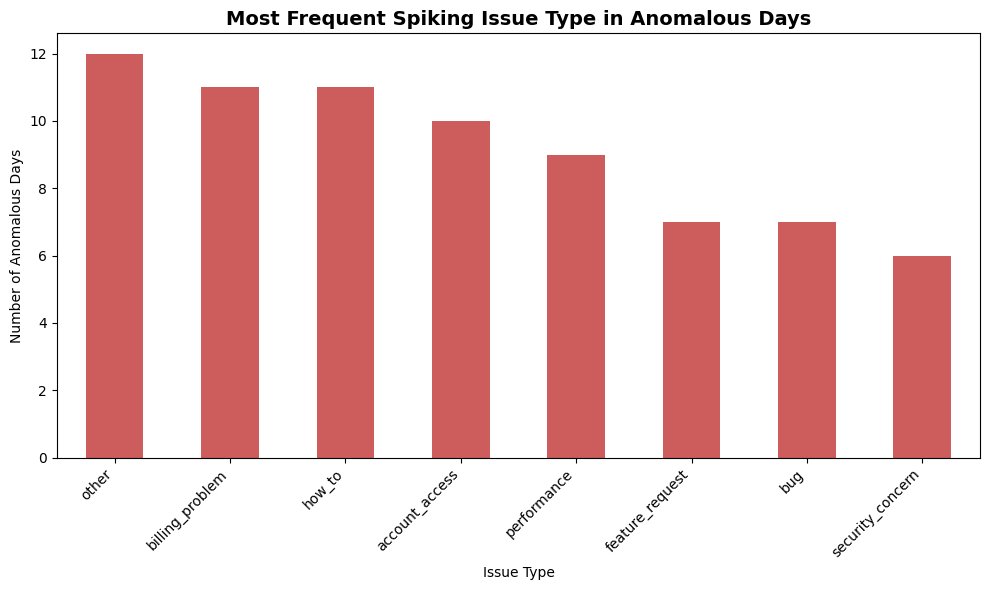

In [64]:
import matplotlib.pyplot as plt

#We verify that the `spiking_issue_type` column exists.
if 'spiking_issue_type' not in anomalies_by_type.columns:
    type_means = daily_by_type[issue_cols].mean()
    type_stds = daily_by_type[issue_cols].std()
    z = (anomalies_by_type[issue_cols] - type_means) / type_stds
    anomalies_by_type['spiking_issue_type'] = z.idxmax(axis=1)
    anomalies_by_type['spike_z'] = z.max(axis=1).round(2)

#Frequency of each type appearing as the "dominant cause" on anomalous days.
dominant_counts = anomalies_by_type['spiking_issue_type'].value_counts()
print(dominant_counts)

plt.figure(figsize=(10, 6))
dominant_counts.plot(kind='bar', color='indianred')
plt.title('Most Frequent Spiking Issue Type in Anomalous Days', fontweight='bold', fontsize=14)
plt.xlabel('Issue Type')
plt.ylabel('Number of Anomalous Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('anomaly_Spiking_issue_type.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
# Is the difference between types of problems real or a coincidence?
from scipy.stats import chisquare

# Chi-square:We compare the actual distribution with an even distribution among the species.
counts_all = dominant_counts.reindex(issue_cols, fill_value=0)
stat, p_value = chisquare(counts_all.values)
print(f"Chi-square p-value: {p_value:.3f}")
print("The difference is statistically significant" if p_value < 0.05 else "The difference is not statistically significant (it could be due to chance)")

#Only significant elevations (z ≥ 3) warrant an alert.
strong_spikes = anomalies_by_type[anomalies_by_type['spike_z'] >= 3]
print("\nStrong spikes (z >= 3):", len(strong_spikes))
strong_spikes[['spiking_issue_type', 'spike_z']].sort_values('spike_z', ascending=False)

Chi-square p-value: 0.800
The difference is not statistically significant (it could be due to chance)

Strong spikes (z >= 3): 12


issue_type,spiking_issue_type,spike_z
created_at,,
2024-07-07,feature_request,3.92
2022-01-29,other,3.91
2023-02-12,performance,3.87
2023-06-24,account_access,3.53
2022-01-22,billing_problem,3.34
2023-06-05,other,3.23
2024-04-19,other,3.23
2024-06-21,other,3.23
2025-04-29,bug,3.23


In [66]:
# Detector verification: We inject a known surge and check if it detects it.
test_daily = daily[features].copy()
rng = np.random.default_rng(42)
surge_days = rng.choice(test_daily.index, size=10, replace=False)
test_daily.loc[surge_days, 'ticket_count'] *= 2   #We are doubling the number of tickets in 10 days.

iso_check = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
flags = pd.Series(iso_check.fit_predict(test_daily), index=test_daily.index)
detected = (flags.loc[surge_days] == -1).sum()
print(f"Detected {detected} / {len(surge_days)} injected surges")

Detected 10 / 10 injected surges


## Save Results & Models

In [67]:
#This makes it easier to directly retrieve the results when we start building the dashboard, without needing to re-run all the code from scratch.
daily.to_csv('anomaly_daily_results.csv')
anomalies_by_type.to_csv('anomaly_by_issue_type_results.csv')
routing_results_df.to_csv('team_routing_results.csv', index=False)

#Save models for streamlit
joblib.dump(tfidf, 'tfidf.pkl')
joblib.dump(rf_classifier, 'issue_classifier.pkl')
joblib.dump(le_issue, 'label_encoder.pkl')
joblib.dump(lr_route, 'team_routing_model.pkl')
print("Saved!")

Saved!


In [68]:
from google.colab import files
import sklearn
print("sklearn version:", sklearn.__version__)

!cd /content && zip dashboard_files.zip final_data.csv anomaly_daily_results.csv anomaly_by_issue_type_results.csv team_routing_results.csv tfidf.pkl issue_classifier.pkl label_encoder.pkl team_routing_model.pkl *.png
files.download('/content/dashboard_files.zip')

sklearn version: 1.6.1
  adding: final_data.csv (deflated 90%)
  adding: anomaly_daily_results.csv (deflated 75%)
  adding: anomaly_by_issue_type_results.csv (deflated 72%)
  adding: team_routing_results.csv (deflated 36%)
  adding: tfidf.pkl (deflated 52%)
  adding: issue_classifier.pkl (deflated 73%)
  adding: label_encoder.pkl (deflated 34%)
  adding: team_routing_model.pkl (deflated 46%)
  adding: anomaly_detection_timeline.png (deflated 2%)
  adding: anomaly_resolution_time.png (deflated 2%)
  adding: anomaly_Spiking_issue_type.png (deflated 21%)
  adding: bert_vs_tfidf.png (deflated 28%)
  adding: issue_type_confusion_matrix.png (deflated 15%)
  adding: issue_type_feature_importance.png (deflated 28%)
  adding: outliers_boxplot.png (deflated 34%)
  adding: resolution_time_mutual_info.png (deflated 24%)
  adding: routing_confusion_matrix.png (deflated 13%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
import sklearn
print(sklearn.__version__)

1.6.1


In [70]:
import joblib, os
joblib.dump(rf_classifier, 'issue_classifier.pkl', compress=3)
for f in ['issue_classifier.pkl', 'team_routing_model.pkl', 'tfidf.pkl', 'final_data.csv']:
    print(f, round(os.path.getsize(f) / 1e6, 1), 'MB')

issue_classifier.pkl 0.9 MB
team_routing_model.pkl 0.0 MB
tfidf.pkl 0.0 MB
final_data.csv 35.5 MB


In [71]:
import pandas as pd, os
from google.colab import files

cols = ['created_at', 'status', 'csat_score', 'resolution_time_hours', 'reopened',
        'product_area', 'issue_type', 'initial_message',
        'channel', 'platform', 'customer_segment']

df_slim = pd.read_csv('final_data.csv', usecols=cols)
df_slim.to_csv('final_data.csv', index=False)
print('final_data.csv', round(os.path.getsize('final_data.csv') / 1e6, 1), 'MB')

files.download('final_data.csv')
files.download('issue_classifier.pkl')

final_data.csv 14.9 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>